# Quartile Analysis — Milton (N=21)

**Objective**: Test whether mobility disruption and recovery metrics differ
across income quartiles using non-parametric methods.

**DVs**:
- `largest_drop` (within) — max % reduction from SARIMAX baseline
- `recovery_days` (within) — trend-based recovery time
- `largest_increase` (outflow) — max % increase above baseline
- `total_disruption` — recovery_days × |largest_drop| (composite)

**Grouping variable**: `median_household_income` split into quartiles

**Tests**:
- Kruskal-Wallis H test (non-parametric, tests whether rank distributions differ across groups)
- Mann-Whitney U pairwise follow-up (Q1 vs Q4, Q1 vs Q2+Q3+Q4)
- Boxplots with individual data points and statistical annotations

In [33]:
import pandas as pd
import numpy as np
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import kruskal, mannwhitneyu, spearmanr

warnings.filterwarnings("ignore", category=FutureWarning)

OUTPUT_DIR = "../results/quartile_analysis_milton/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "figures"), exist_ok=True)
print("Setup complete.")

Setup complete.


## 1. Load and Prepare Data

In [34]:
# ── Load Milton results ──
results_dir = "../results/milton/"

drop_df = pd.read_csv(os.path.join(results_dir, "largest_drop_within.csv"))
recovery_df = pd.read_csv(os.path.join(results_dir, "recovery_within.csv"))
outflow_df = pd.read_csv(os.path.join(results_dir, "outflow_increase.csv"))

# ── Load ACS + county names + distance ──
acs_df = pd.read_csv("acs_socioeconomic_v2.csv")
geo_idx = pd.read_csv("geoid_idx_names.csv")
dist_df = pd.read_csv("../results/spatial_diagnostics_milton/county_distance_to_track.csv")

for d in [drop_df, recovery_df, outflow_df, acs_df, geo_idx, dist_df]:
    d["GEOID"] = d["GEOID"].astype(int)

# ── Merge ──
df = drop_df[["GEOID", "largest_drop"]].merge(
    recovery_df[["GEOID", "recovery_days"]], on="GEOID", how="outer"
).merge(
    outflow_df[["GEOID", "largest_increase"]], on="GEOID", how="outer"
).merge(
    acs_df[["GEOID", "total_population", "median_household_income",
            "pct_no_vehicle", "insurance_coverage_pct"]], on="GEOID"
).merge(
    geo_idx[["GEOID", "NAME"]], on="GEOID"
).merge(
    dist_df[["GEOID", "dist_to_track_mi"]], on="GEOID"
)

# ── Load NCHS urban-rural classification ──
nchs = pd.read_csv("../data/NCHS Urban-Rural Classification Scheme for Counties.csv", encoding='utf-8-sig')
nchs["GEOID"] = nchs["Location"].astype(int)
nchs["nchs_code"] = nchs["2023 Code"].str.extract(r"(\d)").astype(int)
nchs["nchs_label"] = nchs["2023 Code"]
df = df.merge(nchs[["GEOID", "nchs_code", "nchs_label"]], on="GEOID", how="left")

# ── Add education and race from ACS ──
df = df.merge(
    acs_df[["GEOID", "pct_bachelors_plus", "pct_white"]], on="GEOID", how="left"
)

NCHS_LABELS = {
    1: "Large central metro", 2: "Large fringe metro", 3: "Medium metro",
    4: "Small metro", 5: "Micropolitan", 6: "Noncore (rural)",
}

# ── Compute composite DV ──
df["abs_drop"] = df["largest_drop"].abs()
df["total_disruption"] = df["recovery_days"] * df["abs_drop"]

print(f"N = {len(df)} counties")
display(df[["NAME", "median_household_income", "largest_drop", "recovery_days",
            "largest_increase", "total_disruption", "dist_to_track_mi"]].sort_values(
    "median_household_income").to_string(index=False))

N = 21 counties


'        NAME  median_household_income  largest_drop  recovery_days  largest_increase  total_disruption  dist_to_track_mi\n      Hardee                  44665.0    -25.778323       4.702109         23.629464        121.212474         18.407624\n      DeSoto                  45000.0    -40.577553       4.143078         32.515765        168.115958         34.944728\n  Okeechobee                  50476.0    -35.535077       6.219785         35.382761        221.020524         59.489780\n   Highlands                  53679.0    -30.990315       4.645906         11.122808        143.978096         44.468651\n    Hernando                  59202.0    -42.456910       5.338690         75.144807        226.664263         66.109596\n        Polk                  60901.0    -35.332908       4.904272         28.760332        173.282178          1.676145\n   Charlotte                  62164.0    -47.237604       4.457580        177.825958        210.565412         43.319139\n     Volusia           

## Feature Distributions (before quartile creation)

Visualize the distribution of each socioeconomic feature across the 21 Milton counties
to understand the data before creating quartile groupings.

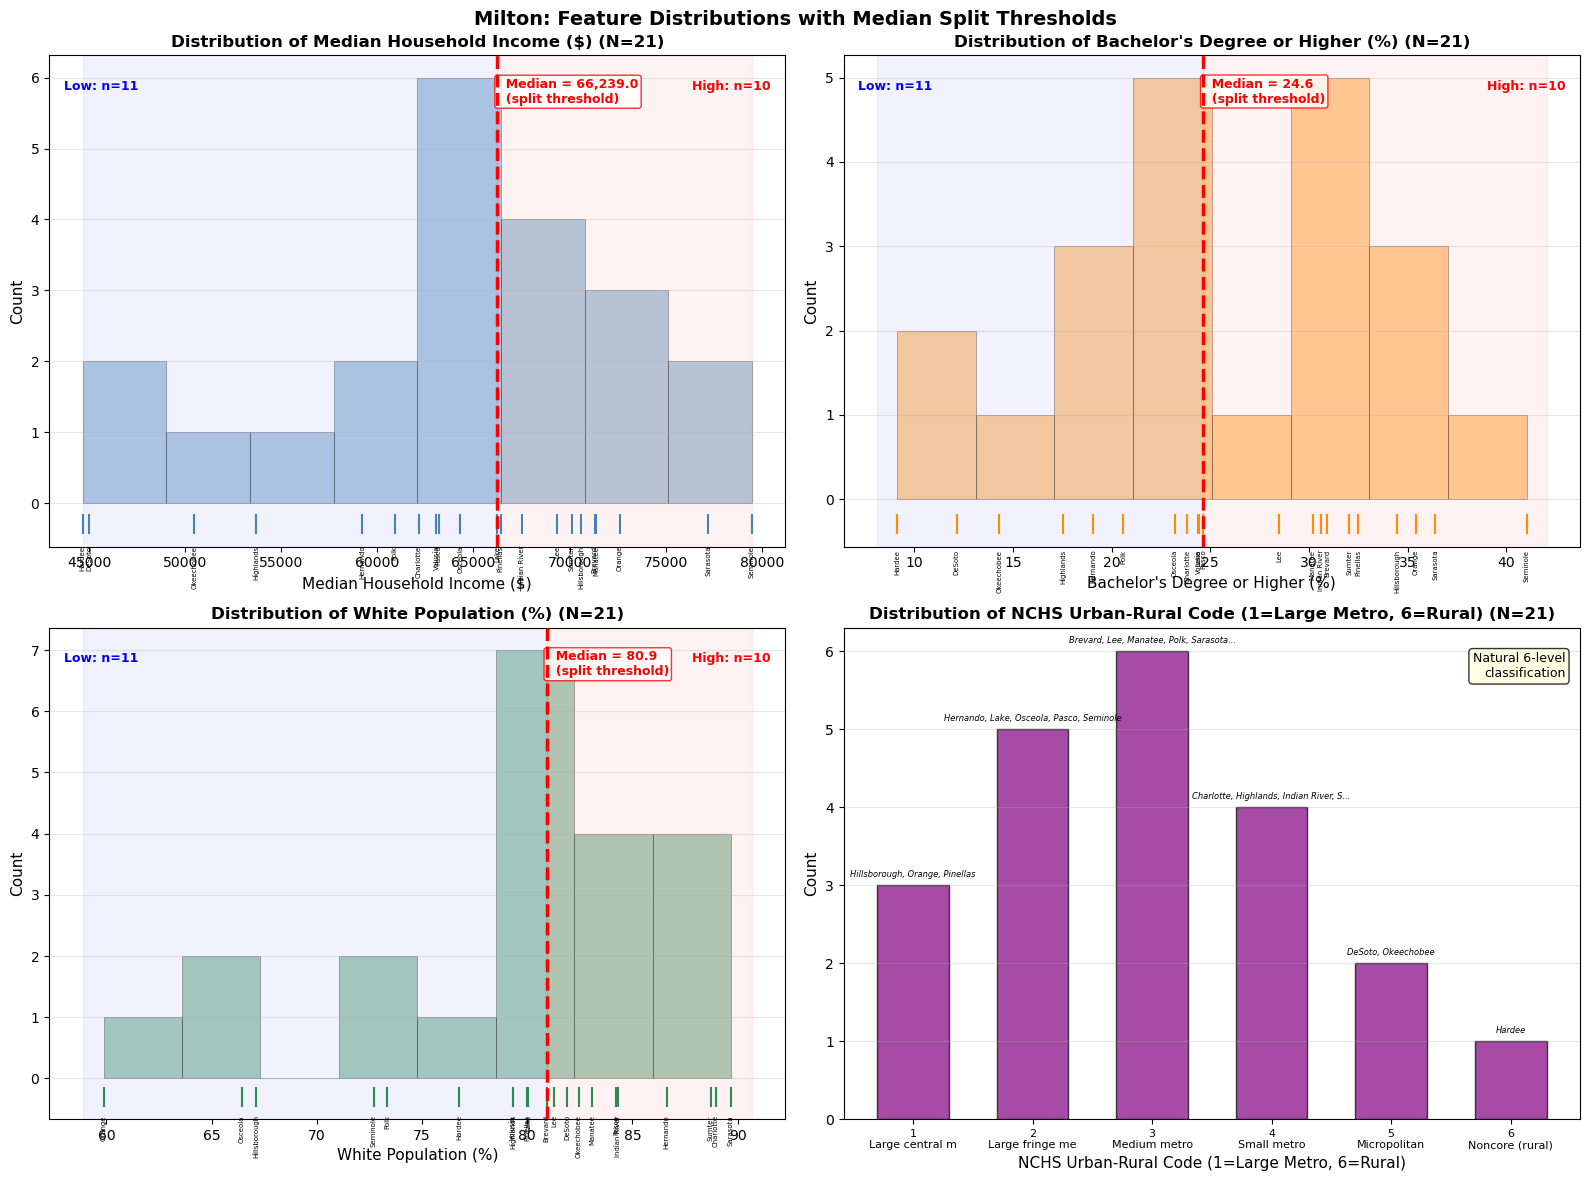


Summary Statistics:

Median Household Income ($):
  Mean=64236.1, Median=66239.0, Std=9462.5, Min=44665.0, Max=79490.0
  Median split: Low (≤66239.0): n=11, High (>66239.0): n=10

Bachelor's Degree or Higher (%):
  Mean=26.0, Median=24.6, Std=8.4, Min=9.1, Max=41.0
  Median split: Low (≤24.6): n=11, High (>24.6): n=10

White Population (%):
  Mean=79.4, Median=80.9, Std=7.8, Min=59.9, Max=89.7
  Median split: Low (≤80.9): n=11, High (>80.9): n=10

NCHS Urban-Rural Code (1=Large Metro, 6=Rural):
  Code 1 (Large central metro): 3 counties — Hillsborough, Orange, Pinellas
  Code 2 (Large fringe metro): 5 counties — Hernando, Lake, Osceola, Pasco, Seminole
  Code 3 (Medium metro): 6 counties — Brevard, Lee, Manatee, Polk, Sarasota, Volusia
  Code 4 (Small metro): 4 counties — Charlotte, Highlands, Indian River, Sumter
  Code 5 (Micropolitan): 2 counties — DeSoto, Okeechobee
  Code 6 (Noncore (rural)): 1 counties — Hardee


In [35]:
# ── Distribution of key features with median split thresholds ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

features_to_plot = [
    ("median_household_income", "Median Household Income ($)", "steelblue"),
    ("pct_bachelors_plus", "Bachelor's Degree or Higher (%)", "darkorange"),
    ("pct_white", "White Population (%)", "seagreen"),
    ("nchs_code", "NCHS Urban-Rural Code (1=Large Metro, 6=Rural)", "purple"),
]

for ax, (col, label, color) in zip(axes.flat, features_to_plot):
    vals = df[col].dropna()
    
    if col == "nchs_code":
        # Bar chart for categorical variable
        counts = df["nchs_code"].value_counts().sort_index()
        bars = ax.bar(counts.index, counts.values, color=color, edgecolor="black",
                      alpha=0.7, width=0.6)
        ax.set_xticks(counts.index)
        ax.set_xticklabels([f"{k}\n{NCHS_LABELS.get(k, '')[:15]}" for k in counts.index],
                          fontsize=8, rotation=0)
        # Label bars with county names
        for code in counts.index:
            counties_in = df[df["nchs_code"] == code]["NAME"].tolist()
            names_str = ", ".join(counties_in)
            if len(names_str) > 40:
                names_str = names_str[:37] + "..."
            ax.text(code, counts[code] + 0.1, names_str,
                    ha="center", fontsize=6, style="italic")
        ax.set_ylabel("Count", fontsize=11)
        # Add note: NCHS uses natural grouping, not median split
        ax.text(0.98, 0.95, "Natural 6-level\nclassification",
                transform=ax.transAxes, fontsize=9, ha="right", va="top",
                bbox=dict(boxstyle="round", fc="lightyellow", alpha=0.8))
    else:
        # Histogram + individual points
        ax.hist(vals, bins=8, color=color, alpha=0.4, edgecolor="black", linewidth=0.5)
        # Rug plot with county names
        for _, row in df.iterrows():
            v = row[col]
            if pd.notna(v):
                ax.plot(v, -0.3, "|", color=color, markersize=15, markeredgewidth=1.5)
                ax.text(v, -0.6, row["NAME"], fontsize=5, ha="center", va="top",
                        rotation=90)
        ax.set_ylabel("Count", fontsize=11)
        
        # ── Add median split threshold line ──
        med = vals.median()
        ymax = ax.get_ylim()[1]
        ax.axvline(med, color="red", linestyle="--", linewidth=2.5, zorder=10)
        ax.text(med, ymax * 0.95, f"  Median = {med:,.1f}\n  (split threshold)",
                fontsize=9, color="red", fontweight="bold", va="top",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="red", alpha=0.8))
        
        # Shade the two halves
        ax.axvspan(vals.min() - 1, med, alpha=0.05, color="blue", label="Low group")
        ax.axvspan(med, vals.max() + 1, alpha=0.05, color="red", label="High group")
        
        n_low = (vals <= med).sum()
        n_high = (vals > med).sum()
        ax.text(0.02, 0.95, f"Low: n={n_low}", transform=ax.transAxes,
                fontsize=9, color="blue", fontweight="bold", va="top")
        ax.text(0.98, 0.95, f"High: n={n_high}", transform=ax.transAxes,
                fontsize=9, color="red", fontweight="bold", va="top", ha="right")
    
    ax.set_xlabel(label, fontsize=11)
    ax.set_title(f"Distribution of {label} (N={len(vals)})", fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Milton: Feature Distributions with Median Split Thresholds",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figures", "feature_distributions.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── Print summary stats ──
print("\nSummary Statistics:")
print("=" * 70)
for col, label, _ in features_to_plot:
    if col == "nchs_code":
        print(f"\n{label}:")
        for code, cnt in df["nchs_code"].value_counts().sort_index().items():
            names = ", ".join(df[df["nchs_code"] == code]["NAME"].tolist())
            print(f"  Code {code} ({NCHS_LABELS.get(code, '')}): {cnt} counties — {names}")
    else:
        vals = df[col].dropna()
        med = vals.median()
        print(f"\n{label}:")
        print(f"  Mean={vals.mean():.1f}, Median={med:.1f}, "
              f"Std={vals.std():.1f}, Min={vals.min():.1f}, Max={vals.max():.1f}")
        print(f"  Median split: Low (≤{med:.1f}): n={(vals <= med).sum()}, "
              f"High (>{med:.1f}): n={(vals > med).sum()}")

In [36]:
# ── Create grouping variables: 2 groups (median split) ──
split_labels = ["Low", "High"]
nchs_split_labels = ["Metro (1-3)", "Non-metro (4-6)"]

GROUPING_CONFIGS = {
    "income_group": {
        "col": "median_household_income",
        "label": "Income",
        "labels": split_labels,
        "is_median_split": True,
    },
    "education_group": {
        "col": "pct_bachelors_plus",
        "label": "Education (% Bachelor's+)",
        "labels": split_labels,
        "is_median_split": True,
    },
    "race_group": {
        "col": "pct_white",
        "label": "Race (% White)",
        "labels": split_labels,
        "is_median_split": True,
    },
    "nchs_group": {
        "col": "nchs_code",
        "label": "Urban-Rural (NCHS)",
        "labels": nchs_split_labels,
        "is_median_split": False,
    },
}

# Median split for income/education/race
for grp_key, grp_cfg in GROUPING_CONFIGS.items():
    if grp_cfg.get("is_median_split", False):
        med = df[grp_cfg["col"]].median()
        df[grp_key] = np.where(df[grp_cfg["col"]] <= med, "Low", "High")
        df[grp_key] = pd.Categorical(df[grp_key], categories=split_labels, ordered=True)

# For NCHS: binary split — Metro (codes 1-3) vs Non-metro (codes 4-6)
df["nchs_group"] = np.where(df["nchs_code"] <= 3, "Metro (1-3)", "Non-metro (4-6)")
df["nchs_group"] = pd.Categorical(df["nchs_group"], categories=nchs_split_labels, ordered=True)

# Show assignments
for grp_key, grp_cfg in GROUPING_CONFIGS.items():
    col = grp_cfg["col"]
    print(f"\n{grp_cfg['label']}:")
    for q in grp_cfg["labels"]:
        sub = df[df[grp_key] == q]
        if len(sub) > 0:
            print(f"  {q}: n={len(sub)}, counties: {', '.join(sub['NAME'].tolist())}")
        else:
            print(f"  {q}: n=0")


Income:
  Low: n=11, counties: Charlotte, DeSoto, Hardee, Hernando, Highlands, Lake, Okeechobee, Osceola, Pasco, Polk, Volusia
  High: n=10, counties: Brevard, Hillsborough, Indian River, Lee, Manatee, Orange, Pinellas, Sarasota, Seminole, Sumter

Education (% Bachelor's+):
  Low: n=11, counties: Charlotte, DeSoto, Hardee, Hernando, Highlands, Lake, Okeechobee, Osceola, Pasco, Polk, Volusia
  High: n=10, counties: Brevard, Hillsborough, Indian River, Lee, Manatee, Orange, Pinellas, Sarasota, Seminole, Sumter

Race (% White):
  Low: n=11, counties: Brevard, Hardee, Highlands, Hillsborough, Lake, Orange, Osceola, Pinellas, Polk, Seminole, Volusia
  High: n=10, counties: Charlotte, DeSoto, Hernando, Indian River, Lee, Manatee, Okeechobee, Pasco, Sarasota, Sumter

Urban-Rural (NCHS):
  Metro (1-3): n=14, counties: Brevard, Hernando, Hillsborough, Lake, Lee, Manatee, Orange, Osceola, Pasco, Pinellas, Polk, Sarasota, Seminole, Volusia
  Non-metro (4-6): n=7, counties: Charlotte, DeSoto, Har

## 2. Mann-Whitney U Tests (2-group comparison)

For each DV × grouping, test H₀: the two groups have the same distribution.
Mann-Whitney U is the non-parametric test for comparing two independent groups.
Also report effect size (rank-biserial correlation r) and Spearman correlation with the raw feature.

In [37]:
DV_CONFIGS = {
    "largest_drop": {
        "col": "largest_drop",
        "label": "Largest Drop — Within (%)",
        "note": "More negative = larger disruption",
    },
    "recovery_days": {
        "col": "recovery_days",
        "label": "Recovery Time — Within (days)",
        "note": "Higher = slower recovery",
    },
    "largest_increase": {
        "col": "largest_increase",
        "label": "Outflow Increase (%)",
        "note": "Higher = more evacuation",
    },
    "total_disruption": {
        "col": "total_disruption",
        "label": "Total Disruption (days × %)",
        "note": "recovery_days × |largest_drop|",
    },
}

quartile_labels = ["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]

In [38]:
def run_two_group_test(df, dv_col, dv_label, group_col, group_labels):
    """
    Mann-Whitney U test for 2-group comparison.
    Also computes rank-biserial effect size r = 1 - 2U/(n1*n2).
    """
    from scipy.stats import mannwhitneyu, spearmanr
    
    groups = [df[df[group_col] == q][dv_col].dropna().values for q in group_labels]
    groups = [g for g in groups if len(g) > 0]
    
    result = {"dv": dv_label, "n_groups": len(groups)}
    
    # Print group medians
    print(f"  Group medians:")
    for q in group_labels:
        sub = df[df[group_col] == q][dv_col].dropna()
        if len(sub) > 0:
            print(f"    {q}: median = {sub.median():.2f}, mean = {sub.mean():.2f}, n = {len(sub)}")
    
    if len(groups) < 2 or any(len(g) < 2 for g in groups):
        print(f"  ⚠ Insufficient data for test")
        result.update({"MW_U": None, "MW_p": None, "effect_size_r": None,
                       "spearman_rho": None, "spearman_p": None})
        return result
    
    # Mann-Whitney U test
    u_stat, p_val = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    n1, n2 = len(groups[0]), len(groups[1])
    
    # Rank-biserial effect size: r = 1 - 2U/(n1*n2)
    effect_r = 1 - (2 * u_stat) / (n1 * n2)
    
    sig = "**" if p_val < 0.05 else "*" if p_val < 0.1 else "n.s."
    print(f"  Mann-Whitney U = {u_stat:.1f}, p = {p_val:.4f} {sig}")
    print(f"  Effect size (rank-biserial r) = {effect_r:.3f}")
    
    result.update({
        "MW_U": u_stat,
        "MW_p": p_val,
        "effect_size_r": effect_r,
        "n1": n1,
        "n2": n2,
        "median_group1": float(np.median(groups[0])),
        "median_group2": float(np.median(groups[1])),
    })
    
    # Spearman correlation with raw continuous feature
    if group_col in GROUPING_CONFIGS and GROUPING_CONFIGS[group_col].get("is_median_split", False):
        raw_col = GROUPING_CONFIGS[group_col]["col"]
        valid = df[[raw_col, dv_col]].dropna()
        if len(valid) >= 5:
            rho, sp = spearmanr(valid[raw_col], valid[dv_col])
            print(f"  Spearman (DV vs {raw_col}): ρ = {rho:.3f}, p = {sp:.4f}")
            result.update({"spearman_rho": rho, "spearman_p": sp})
        else:
            result.update({"spearman_rho": None, "spearman_p": None})
    else:
        result.update({"spearman_rho": None, "spearman_p": None})
    
    return result

In [39]:
# ── Run all tests: all groupings × all DVs ──
test_results = []

for grp_key, grp_cfg in GROUPING_CONFIGS.items():
    grp_labels = grp_cfg["labels"]
    for dv_key, cfg in DV_CONFIGS.items():
        print(f"\n{'─'*60}")
        print(f"{cfg['label']}  ×  {grp_cfg['label']}")
        print(f"{'─'*60}")
        
        res = run_two_group_test(df, cfg["col"], cfg["label"], grp_key, grp_labels)
        res["grouping"] = grp_cfg["label"]
        test_results.append(res)

test_df = pd.DataFrame(test_results)

# ── Summary table ──
print("\n\n" + "=" * 80)
print("SUMMARY: All Mann-Whitney U Tests")
print("=" * 80)
summary_cols = ["grouping", "dv", "MW_U", "MW_p", "effect_size_r", "spearman_rho", "spearman_p"]
display(test_df[summary_cols].round(4))

# ── Highlight significant results ──
sig_tests = test_df[test_df["MW_p"].notna() & (test_df["MW_p"] < 0.1)]
if len(sig_tests) > 0:
    print(f"\n🔍 {len(sig_tests)} test(s) with p < 0.10:")
    for _, row in sig_tests.iterrows():
        star = "**" if row["MW_p"] < 0.05 else "*"
        print(f"  {star} {row['grouping']} × {row['dv']}: "
              f"U={row['MW_U']:.0f}, p={row['MW_p']:.4f}, r={row['effect_size_r']:.3f}")
else:
    print("\nNo tests significant at p < 0.10")

test_df.to_csv(os.path.join(OUTPUT_DIR, "mann_whitney_results.csv"), index=False)
print(f"\nSaved to {OUTPUT_DIR}/mann_whitney_results.csv")


────────────────────────────────────────────────────────────
Largest Drop — Within (%)  ×  Income
────────────────────────────────────────────────────────────
  Group medians:
    Low: median = -35.54, mean = -36.18, n = 11
    High: median = -33.19, mean = -33.77, n = 10
  Mann-Whitney U = 44.0, p = 0.4597 n.s.
  Effect size (rank-biserial r) = 0.200
  Spearman (DV vs median_household_income): ρ = 0.148, p = 0.5219

────────────────────────────────────────────────────────────
Recovery Time — Within (days)  ×  Income
────────────────────────────────────────────────────────────
  Group medians:
    Low: median = 4.84, mean = 4.89, n = 11
    High: median = 4.79, mean = 4.85, n = 10
  Mann-Whitney U = 54.0, p = 0.9719 n.s.
  Effect size (rank-biserial r) = 0.018
  Spearman (DV vs median_household_income): ρ = 0.040, p = 0.8624

────────────────────────────────────────────────────────────
Outflow Increase (%)  ×  Income
────────────────────────────────────────────────────────────
  Group

,grouping,dv,MW_U,MW_p,effect_size_r,spearman_rho,spearman_p
0,Income,Largest Drop — Within (%),44.0,0.4597,0.2000,0.1481,0.5219
1,Income,Recovery Time — Within (days),54.0,0.9719,0.0182,0.0403,0.8624
2,Income,Outflow Increase (%),43.0,0.4181,0.2182,0.1338,0.5632
3,Income,Total Disruption (days × %),68.0,0.3787,-0.2364,-0.1948,0.3974
4,Education (% Bachelor's+),Largest Drop — Within (%),44.0,0.4597,0.2000,0.1130,0.6258
5,Education (% Bachelor's+),Recovery Time — Within (days),54.0,0.9719,0.0182,0.1156,0.6178
6,Education (% Bachelor's+),Outflow Increase (%),43.0,0.4181,0.2182,0.1935,0.4007
7,Education (% Bachelor's+),Total Disruption (days × %),68.0,0.3787,-0.2364,-0.1338,0.5632
8,Race (% White),Largest Drop — Within (%),84.0,0.0448,-0.5273,-0.2364,0.3023
9,Race (% White),Recovery Time — Within (days),64.0,0.5495,-0.1636,-0.0364,0.8756



🔍 4 test(s) with p < 0.10:
  ** Race (% White) × Largest Drop — Within (%): U=84, p=0.0448, r=-0.527
  ** Race (% White) × Outflow Increase (%): U=17, p=0.0083, r=0.691
  * Race (% White) × Total Disruption (days × %): U=29, p=0.0725, r=0.473
  * Urban-Rural (NCHS) × Recovery Time — Within (days): U=74, p=0.0667, r=-0.510

Saved to ../results/quartile_analysis_milton//mann_whitney_results.csv


## 3. Boxplots (2-group comparison)

For each DV × grouping: side-by-side boxplots with individual points,
colored by distance to track. Mann-Whitney p-value annotated.

In [40]:
def plot_two_group_boxplot(df, dv_col, dv_label, dv_note, group_col,
                           group_labels, mw_p, effect_r, save_path=None):
    """
    Boxplot comparing 2 groups with individual points colored by distance-to-track,
    county name annotations, and Mann-Whitney test results.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Boxplot
    box_data = [df[df[group_col] == q][dv_col].dropna().values for q in group_labels]
    bp = ax.boxplot(box_data, positions=range(len(group_labels)),
                    widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor="lightblue", alpha=0.5),
                    medianprops=dict(color="red", linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))

    # Color boxes differently
    colors_box = ["#4C72B0", "#DD8452"]
    for patch, c in zip(bp["boxes"], colors_box):
        patch.set_facecolor(c)
        patch.set_alpha(0.3)

    # Overlay individual points colored by distance
    norm = plt.Normalize(df["dist_to_track_mi"].min(), df["dist_to_track_mi"].max())
    cmap = plt.cm.RdYlGn_r
    np.random.seed(42)
    for i, q in enumerate(group_labels):
        sub = df[df[group_col] == q].dropna(subset=[dv_col])
        if len(sub) == 0:
            continue
        jitter = np.random.uniform(-0.15, 0.15, size=len(sub))
        sc = ax.scatter(np.full(len(sub), i) + jitter, sub[dv_col],
                        c=sub["dist_to_track_mi"], cmap=cmap, norm=norm,
                        s=60, edgecolors="black", linewidth=0.5, zorder=5)
        # Annotate county names
        for _, row in sub.iterrows():
            ax.annotate(row["NAME"], (i + jitter[sub.index.get_loc(row.name)], row[dv_col]),
                        fontsize=6, ha="center", va="bottom",
                        xytext=(0, 5), textcoords="offset points", rotation=30)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label("Distance to Track (mi)", fontsize=10)

    # Statistical annotation
    if mw_p is not None:
        sig = "**" if mw_p < 0.05 else "*" if mw_p < 0.1 else "n.s."
        sig_text = f"Mann-Whitney p = {mw_p:.3f} {sig}"
        if effect_r is not None:
            sig_text += f"\nEffect size r = {effect_r:.3f}"
    else:
        sig_text = "Test not available"
    
    # Add bracket between groups
    y_max = df[dv_col].max()
    y_range = df[dv_col].max() - df[dv_col].min()
    bracket_y = y_max + y_range * 0.1
    ax.plot([0, 0, 1, 1], [bracket_y, bracket_y + y_range*0.02,
             bracket_y + y_range*0.02, bracket_y], color="black", lw=1.5)
    ax.text(0.5, bracket_y + y_range * 0.04, sig_text,
            ha="center", fontsize=10, fontweight="bold",
            color="darkred" if mw_p is not None and mw_p < 0.05 else
                  "darkorange" if mw_p is not None and mw_p < 0.1 else "gray")

    ax.set_xticks(range(len(group_labels)))
    ax.set_xticklabels(group_labels, fontsize=12, fontweight="bold")
    ax.set_ylabel(f"{dv_label}", fontsize=11)
    ax.set_title(f"{dv_label}\n{dv_note}", fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.show()

  Saved: ../results/quartile_analysis_milton/figures/boxplot_largest_drop_by_income_group.png


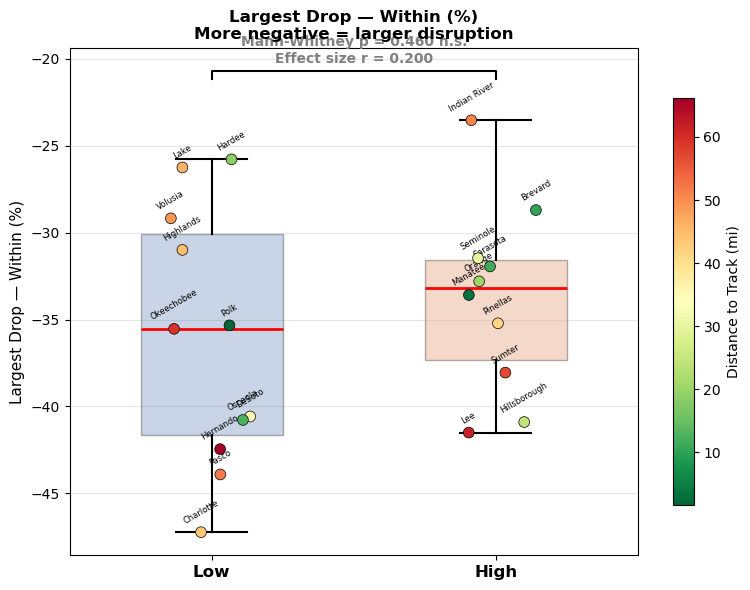

  Saved: ../results/quartile_analysis_milton/figures/boxplot_recovery_days_by_income_group.png


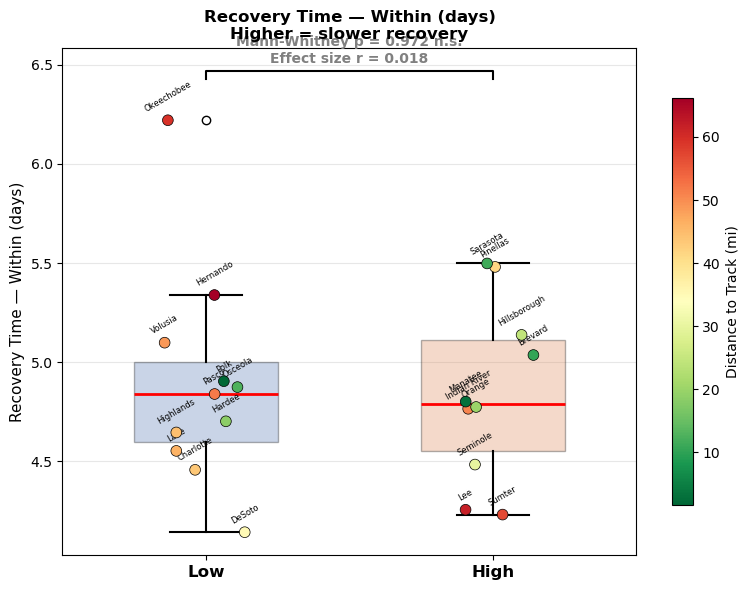

  Saved: ../results/quartile_analysis_milton/figures/boxplot_largest_increase_by_income_group.png


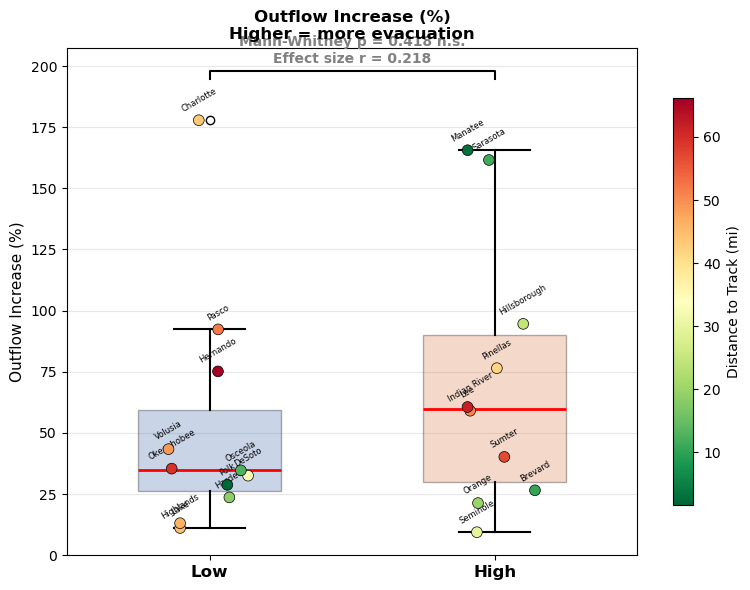

  Saved: ../results/quartile_analysis_milton/figures/boxplot_total_disruption_by_income_group.png


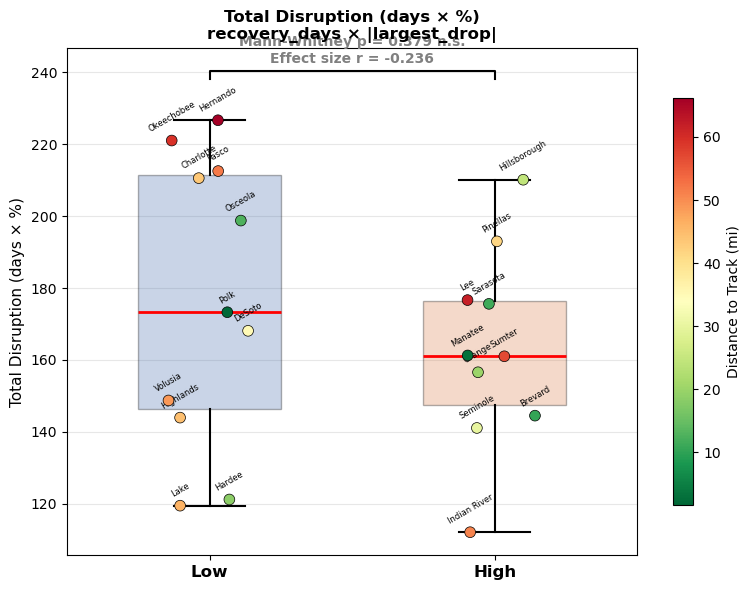

  Saved: ../results/quartile_analysis_milton/figures/boxplot_largest_drop_by_education_group.png


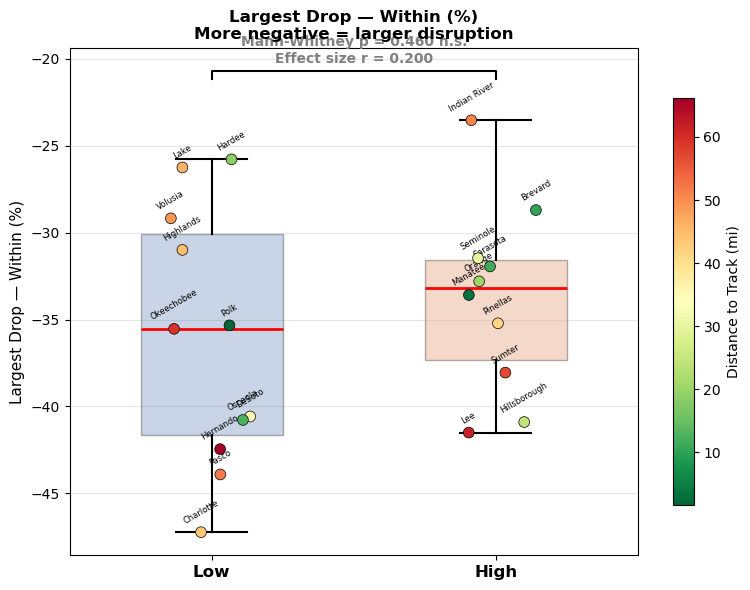

  Saved: ../results/quartile_analysis_milton/figures/boxplot_recovery_days_by_education_group.png


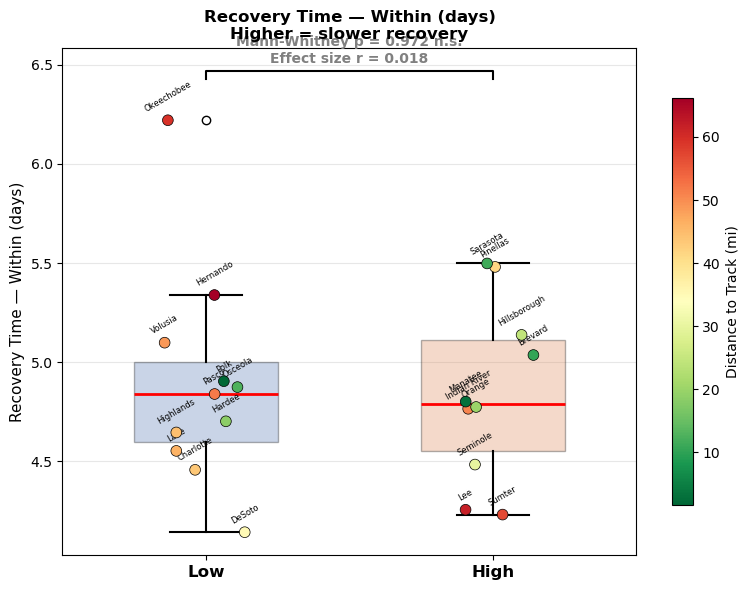

  Saved: ../results/quartile_analysis_milton/figures/boxplot_largest_increase_by_education_group.png


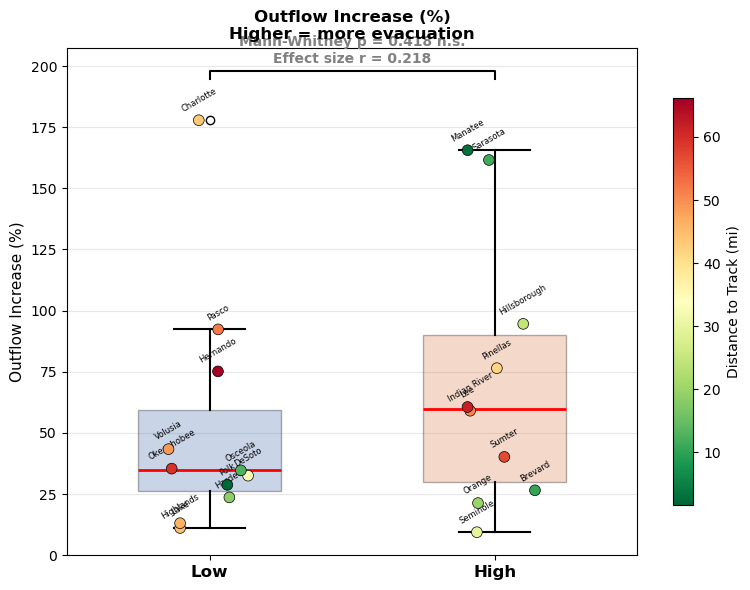

  Saved: ../results/quartile_analysis_milton/figures/boxplot_total_disruption_by_education_group.png


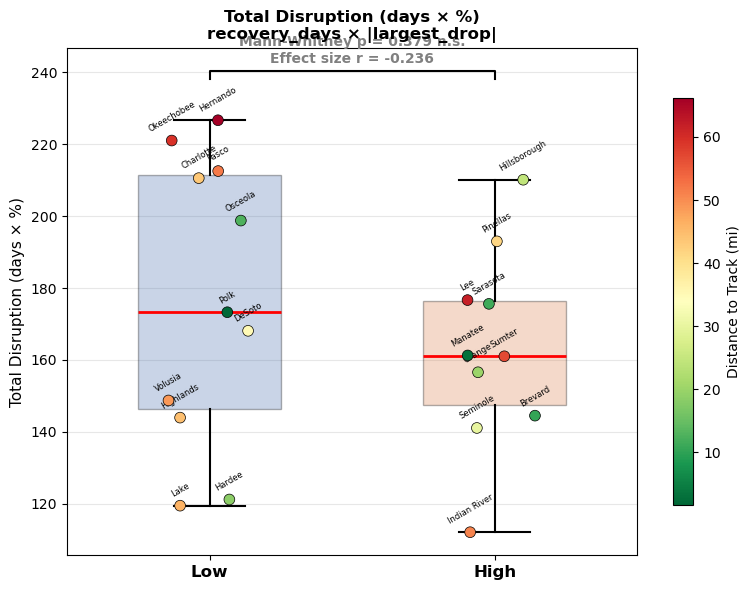

  Saved: ../results/quartile_analysis_milton/figures/boxplot_largest_drop_by_race_group.png


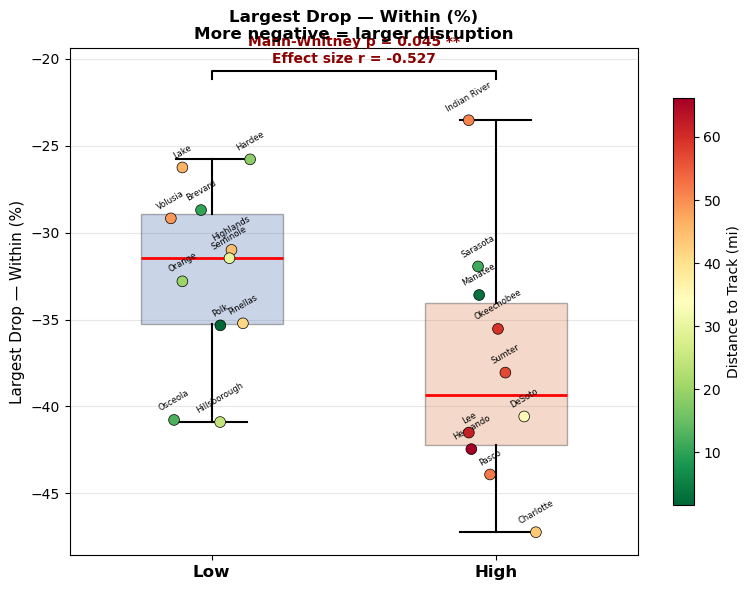

  Saved: ../results/quartile_analysis_milton/figures/boxplot_recovery_days_by_race_group.png


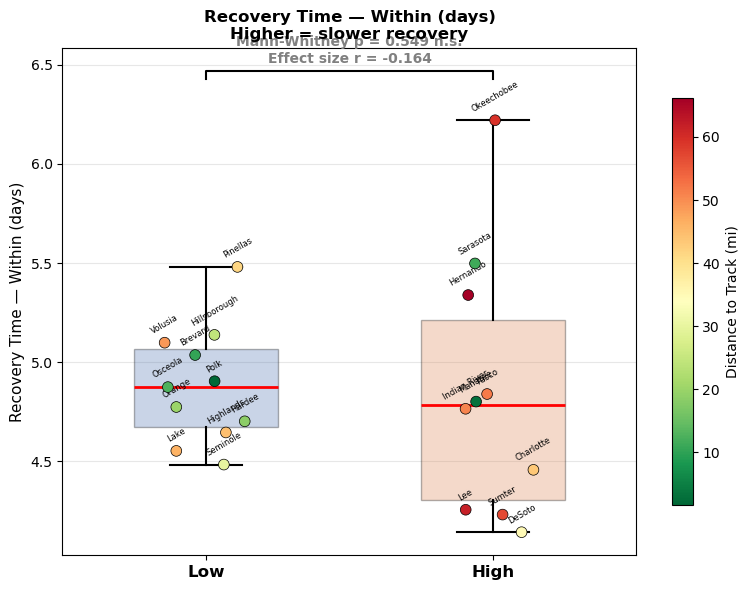

  Saved: ../results/quartile_analysis_milton/figures/boxplot_largest_increase_by_race_group.png


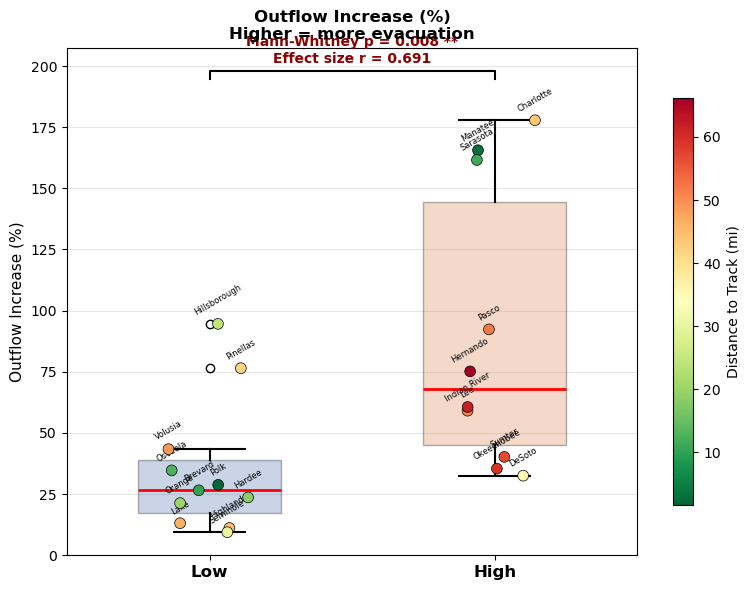

  Saved: ../results/quartile_analysis_milton/figures/boxplot_total_disruption_by_race_group.png


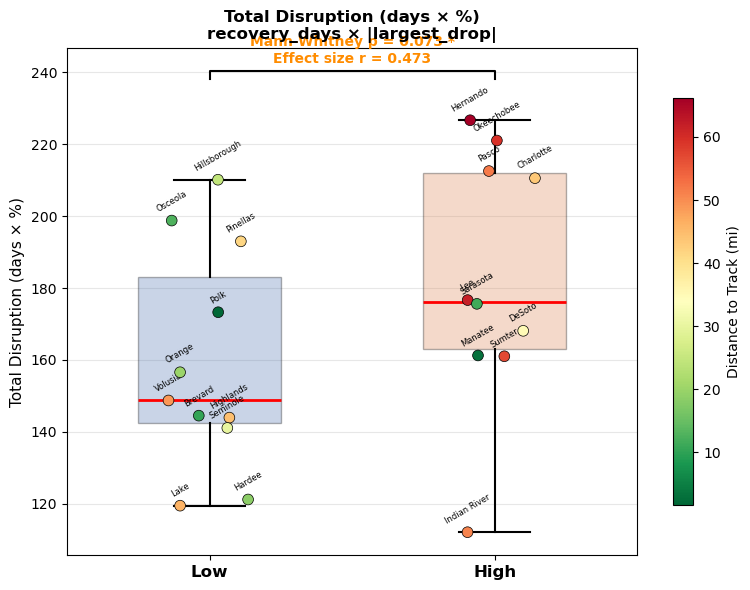

  Saved: ../results/quartile_analysis_milton/figures/boxplot_largest_drop_by_nchs_group.png


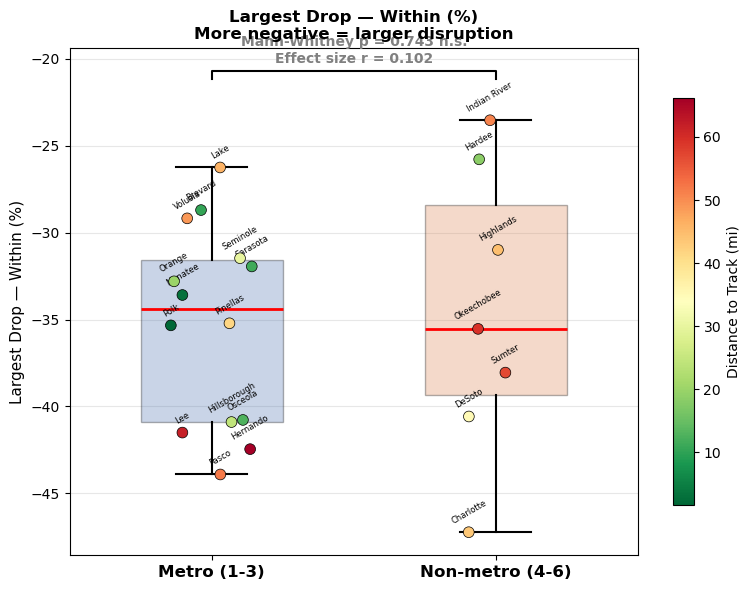

  Saved: ../results/quartile_analysis_milton/figures/boxplot_recovery_days_by_nchs_group.png


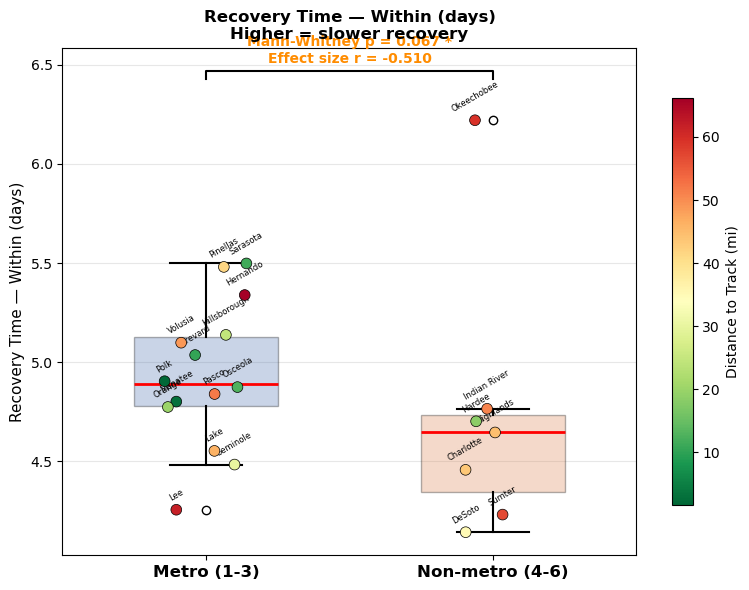

  Saved: ../results/quartile_analysis_milton/figures/boxplot_largest_increase_by_nchs_group.png


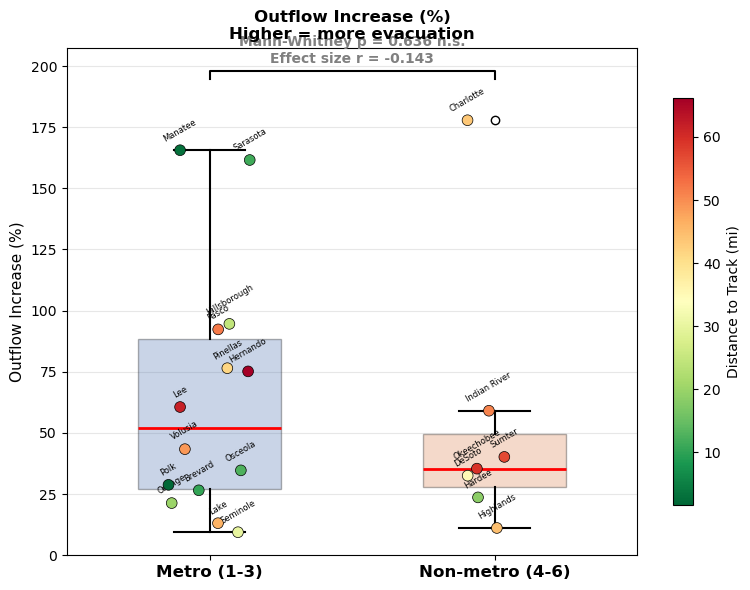

  Saved: ../results/quartile_analysis_milton/figures/boxplot_total_disruption_by_nchs_group.png


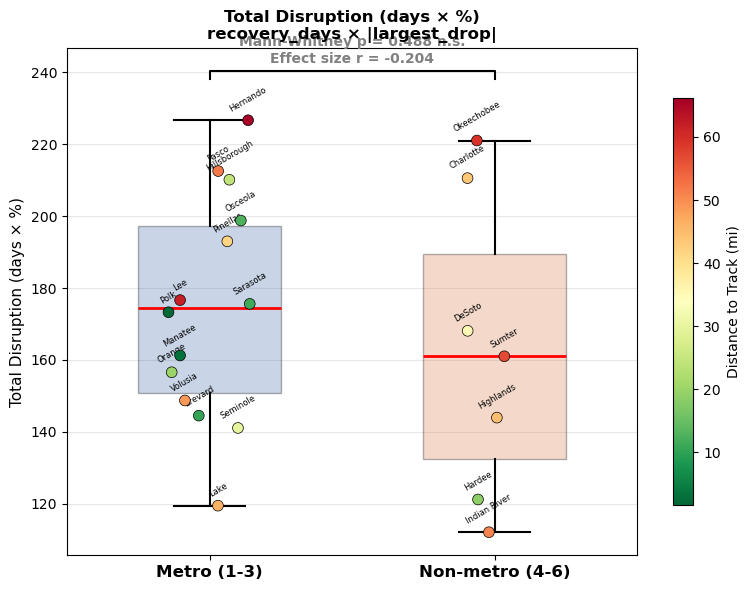

In [41]:
# ── Generate boxplots for ALL groupings ──
for grp_key, grp_cfg in GROUPING_CONFIGS.items():
    grp_labels = grp_cfg["labels"]
    for dv_key, cfg in DV_CONFIGS.items():
        # Get test results for annotation
        res_row = test_df[
            (test_df["grouping"] == grp_cfg["label"]) &
            (test_df["dv"] == cfg["label"])
        ]
        mw_p = None
        effect_r = None
        if len(res_row) > 0:
            mw_val = res_row.iloc[0]["MW_p"]
            mw_p = float(mw_val) if pd.notna(mw_val) else None
            r_val = res_row.iloc[0]["effect_size_r"]
            effect_r = float(r_val) if pd.notna(r_val) else None
        
        plot_two_group_boxplot(
            df, cfg["col"], cfg["label"], cfg["note"],
            grp_key, grp_labels,
            mw_p, effect_r,
            os.path.join(OUTPUT_DIR, f"figures/boxplot_{dv_key}_by_{grp_key}.png")
        )

## 4. Combined Panel Figure

All 4 DVs × 4 groupings in a grid. Each cell shows 2-group boxplots with significance.

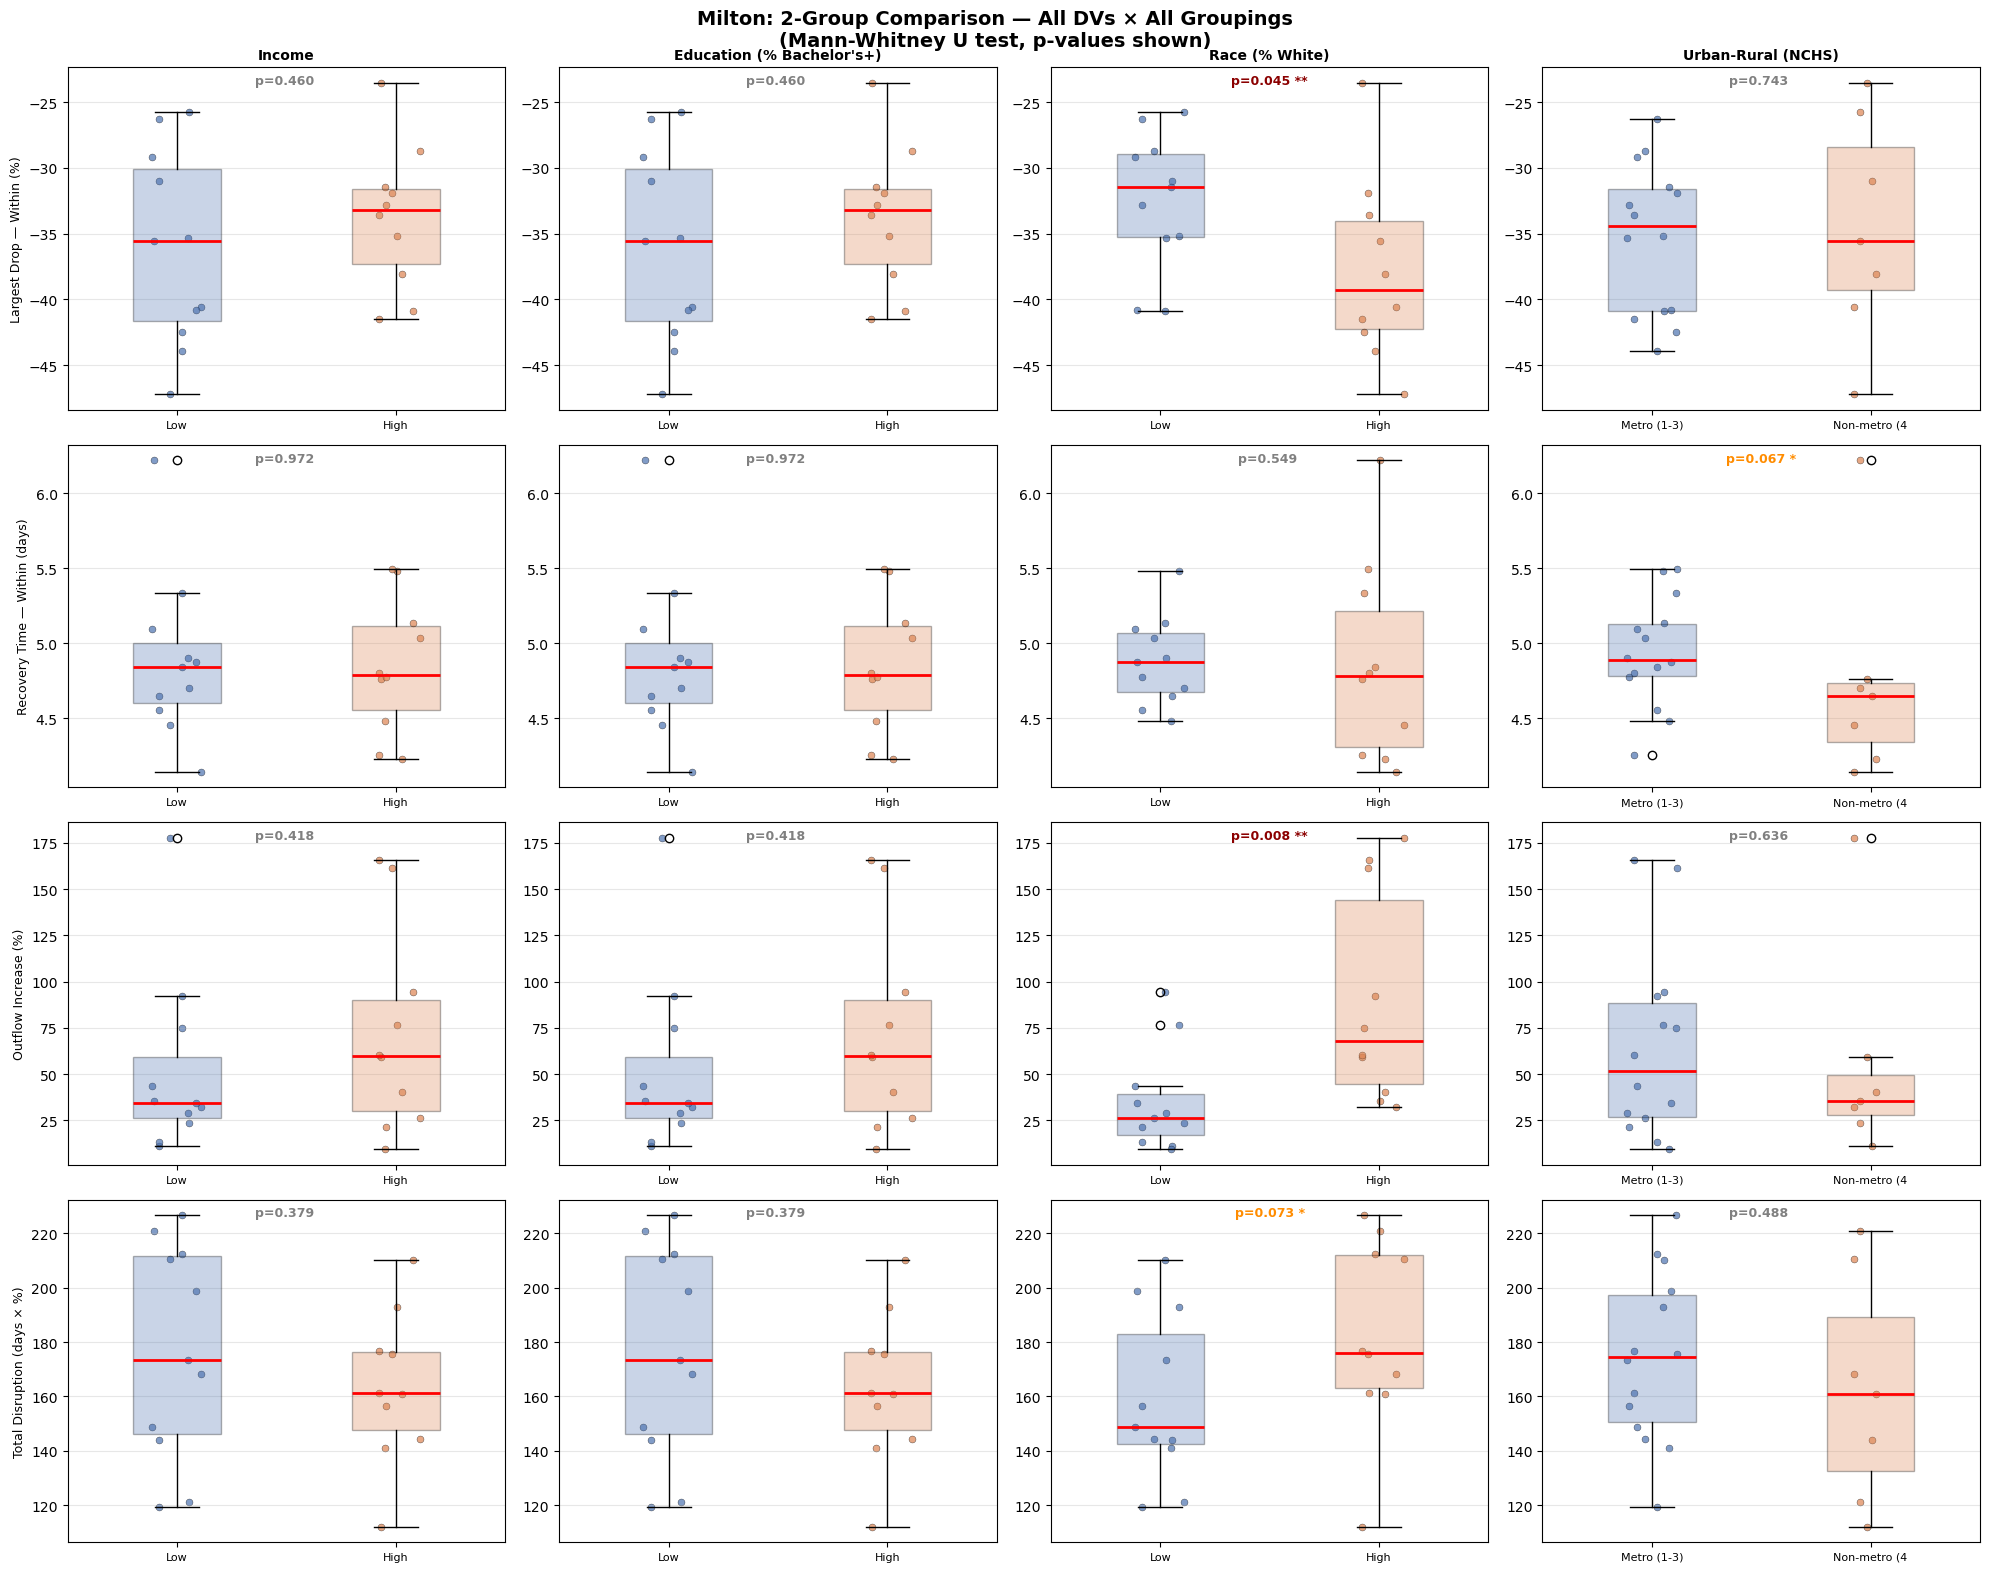

In [42]:
# ── Combined panel: DVs (rows) × Groupings (cols) ──
dv_keys = list(DV_CONFIGS.keys())
grp_keys = list(GROUPING_CONFIGS.keys())
n_dvs = len(dv_keys)
n_grps = len(grp_keys)

fig, axes = plt.subplots(n_dvs, n_grps, figsize=(5 * n_grps, 4 * n_dvs))

colors_box = ["#4C72B0", "#DD8452"]

for row, dv_key in enumerate(dv_keys):
    cfg = DV_CONFIGS[dv_key]
    for col, grp_key in enumerate(grp_keys):
        ax = axes[row, col]
        grp_cfg = GROUPING_CONFIGS[grp_key]
        grp_labels = grp_cfg["labels"]
        
        box_data = [df[df[grp_key] == q][cfg["col"]].dropna().values for q in grp_labels]
        bp = ax.boxplot(box_data, positions=range(len(grp_labels)),
                        widths=0.4, patch_artist=True,
                        medianprops=dict(color="red", linewidth=2))
        for patch, c in zip(bp["boxes"], colors_box[:len(grp_labels)]):
            patch.set_facecolor(c)
            patch.set_alpha(0.3)
        
        # Overlay points
        np.random.seed(42)
        for i, q in enumerate(grp_labels):
            sub = df[df[grp_key] == q][cfg["col"]].dropna()
            jitter = np.random.uniform(-0.12, 0.12, size=len(sub))
            ax.scatter(np.full(len(sub), i) + jitter, sub,
                       s=25, alpha=0.7, edgecolors="black", linewidth=0.3, c=colors_box[min(i, 1)])
        
        # p-value annotation
        res_row = test_df[
            (test_df["grouping"] == grp_cfg["label"]) &
            (test_df["dv"] == cfg["label"])
        ]
        if len(res_row) > 0 and pd.notna(res_row.iloc[0]["MW_p"]):
            p = float(res_row.iloc[0]["MW_p"])
            sig = "**" if p < 0.05 else "*" if p < 0.1 else ""
            color = "darkred" if p < 0.05 else "darkorange" if p < 0.1 else "gray"
            ax.text(0.5, 0.98, f"p={p:.3f} {sig}", transform=ax.transAxes,
                    ha="center", va="top", fontsize=9, fontweight="bold", color=color)
        
        ax.set_xticks(range(len(grp_labels)))
        # Shorter labels for panel
        short_labels = [l[:12] for l in grp_labels]
        ax.set_xticklabels(short_labels, fontsize=8)
        ax.grid(axis="y", alpha=0.3)
        
        if col == 0:
            ax.set_ylabel(cfg["label"], fontsize=9)
        if row == 0:
            ax.set_title(grp_cfg["label"], fontsize=10, fontweight="bold")

fig.suptitle("Milton: 2-Group Comparison — All DVs × All Groupings\n(Mann-Whitney U test, p-values shown)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figures", "panel_boxplots_2group.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 5. Descriptive Summary Table

In [43]:
# ── Descriptive statistics per group ──
desc_rows = []

for grp_key, grp_cfg in GROUPING_CONFIGS.items():
    for q in grp_cfg["labels"]:
        sub = df[df[grp_key] == q]
        if len(sub) == 0:
            continue
        row = {
            "Grouping": grp_cfg["label"],
            "Group": q,
            "N": len(sub),
            "Median drop (%)": round(sub["largest_drop"].median(), 1),
            "Median recovery (days)": round(sub["recovery_days"].median(), 2),
            "Median outflow increase (%)": round(sub["largest_increase"].median(), 1),
            "Median total disruption": round(sub["total_disruption"].median(), 1),
            "Median income ($)": f"{sub['median_household_income'].median():,.0f}",
            "Median dist to track (mi)": round(sub["dist_to_track_mi"].median(), 1),
            "Counties": ", ".join(sorted(sub["NAME"].tolist())),
        }
        desc_rows.append(row)

desc_df = pd.DataFrame(desc_rows)
display(desc_df)
desc_df.to_csv(os.path.join(OUTPUT_DIR, "two_group_descriptives.csv"), index=False)
print(f"Saved to {OUTPUT_DIR}/two_group_descriptives.csv")

,Grouping,Group,N,Median drop (%),Median recovery (days),Median outflow increase (%),Median total disruption,Median income ($),Median dist to track (mi),Counties
0,Income,Low,11,-35.5,4.84,34.7,173.3,"60,901",44.5,"Charlotte, DeSoto, Hardee, Hernando, Highlands..."
1,Income,High,10,-33.2,4.79,59.8,161.1,"70,960",27.2,"Brevard, Hillsborough, Indian River, Lee, Mana..."
2,Education (% Bachelor's+),Low,11,-35.5,4.84,34.7,173.3,"60,901",44.5,"Charlotte, DeSoto, Hardee, Hernando, Highlands..."
3,Education (% Bachelor's+),High,10,-33.2,4.79,59.8,161.1,"70,960",27.2,"Brevard, Hillsborough, Indian River, Lee, Mana..."
4,Race (% White),Low,11,-31.5,4.87,26.5,148.7,"66,239",24.4,"Brevard, Hardee, Highlands, Hillsborough, Lake..."
5,Race (% White),High,10,-39.3,4.78,67.9,176.1,"65,365",51.3,"Charlotte, DeSoto, Hernando, Indian River, Lee..."
6,Urban-Rural (NCHS),Metro (1-3),14,-34.4,4.89,52.0,174.4,"67,887",27.2,"Brevard, Hernando, Hillsborough, Lake, Lee, Ma..."
7,Urban-Rural (NCHS),Non-metro (4-6),7,-35.5,4.65,35.4,161.0,"53,679",44.5,"Charlotte, DeSoto, Hardee, Highlands, Indian R..."


Saved to ../results/quartile_analysis_milton//two_group_descriptives.csv


## 6. Interpretation

**Reading the results:**

| Mann-Whitney p | Interpretation |
|---|---|
| p < 0.05 | Significant difference between groups ** |
| 0.05 ≤ p < 0.10 | Marginal difference * |
| p ≥ 0.10 | No significant difference |

**Effect size (rank-biserial r):**
- |r| < 0.1: negligible
- 0.1 ≤ |r| < 0.3: small
- 0.3 ≤ |r| < 0.5: medium
- |r| ≥ 0.5: large

With N=21 split into two groups (~10-11 each), the Mann-Whitney U test
has more power than the previous 4-quartile Kruskal-Wallis approach.